# Student Dropout Prediction Using Machine Learning

### Objective
To develop a machine learning model that predicts whether a student is at risk of dropout based on academic, personal, and financial factors.

### Algorithms Used
1. Logistic Regression
2. Decision Tree
3. Random Forest

### Technologies Used
- Python
- Google Colab
- Pandas
- NumPy
- Scikit-learn
- Matplotlib
- Seaborn

### Modules
- Data Collection
- Data Preprocessing
- Data Visualization
- Model Training
- Model Evaluation
- Student Prediction

In [ ]:
import pandas as pd
import numpy as np


import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.model_selection import train_test_split


from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler


from sklearn.linear_model import LogisticRegression

from sklearn.tree import DecisionTreeClassifier

from sklearn.ensemble import RandomForestClassifier



from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)


import warnings
warnings.filterwarnings("ignore")

## Dataset Loading

Dataset contains student details:

Features:
- Age
- Gender
- Family Income
- Internet Access
- Study Hours
- Attendance
- GPA
- CGPA
- Stress Level
- Scholarship
- Department

Target:
- Dropout

In [ ]:
df = pd.read_csv(
    "student_dropout_dataset_v3.csv"
)

In [ ]:
df.head()

,Student_ID,Age,Gender,Family_Income,Internet_Access,Study_Hours_per_Day,Attendance_Rate,Assignment_Delay_Days,Travel_Time_Minutes,Part_Time_Job,Scholarship,Stress_Index,GPA,Semester_GPA,CGPA,Semester,Department,Parental_Education,Dropout
0,1,22.1,Male,25000.0,Yes,3.36,86.1,2,20.4,Yes,No,5.5,0.96,0.90,0.90,Year 1,Arts,High School,0
1,2,20.7,Male,25000.0,Yes,4.30,68.0,2,44.0,No,No,6.8,1.28,1.20,1.19,Year 3,Engineering,Bachelor,1
2,3,22.4,Male,40183.0,Yes,4.40,70.9,0,48.9,Yes,No,5.5,1.68,1.32,1.32,Year 1,Arts,Master,0
3,4,24.4,Male,NaN,Yes,NaN,82.2,2,38.6,No,No,NaN,1.78,1.77,1.77,Year 1,CS,High School,1
4,5,20.5,Female,25319.0,Yes,4.19,75.7,1,23.0,No,No,7.0,1.48,0.91,0.87,Year 4,Business,Bachelor,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 19 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Student_ID             10000 non-null  int64  
 1   Age                    10000 non-null  float64
 2   Gender                 10000 non-null  object 
 3   Family_Income          9500 non-null   float64
 4   Internet_Access        10000 non-null  object 
 5   Study_Hours_per_Day    9500 non-null   float64
 6   Attendance_Rate        10000 non-null  float64
 7   Assignment_Delay_Days  10000 non-null  int64  
 8   Travel_Time_Minutes    10000 non-null  float64
 9   Part_Time_Job          10000 non-null  object 
 10  Scholarship            10000 non-null  object 
 11  Stress_Index           9500 non-null   float64
 12  GPA                    10000 non-null  float64
 13  Semester_GPA           10000 non-null  float64
 14  CGPA                   10000 non-null  float64
 15  Sem

In [ ]:
df.describe()

,Student_ID,Age,Family_Income,Study_Hours_per_Day,Attendance_Rate,Assignment_Delay_Days,Travel_Time_Minutes,Stress_Index,GPA,Semester_GPA,CGPA,Dropout
count,10000.00000,10000.00000,9500.000000,9500.000000,10000.00000,10000.000000,10000.00000,9500.000000,10000.000000,10000.000000,10000.000000,10000.00000
mean,5000.50000,21.02606,38377.247474,4.014592,81.73683,1.799700,30.17926,5.507147,2.308440,2.300057,2.298761,0.23540
std,2886.89568,2.13981,20496.232179,1.295450,8.22093,1.344307,11.91887,1.765951,1.061717,1.074407,1.072555,0.42427
min,1.00000,17.00000,25000.000000,0.500000,38.20000,0.000000,5.00000,1.000000,0.000000,0.000000,0.000000,0.00000
25%,2500.75000,19.50000,25000.000000,3.160000,76.40000,1.000000,21.90000,4.300000,1.550000,1.520000,1.520000,0.00000
50%,5000.50000,21.00000,29740.500000,4.000000,81.80000,2.000000,30.20000,5.500000,2.350000,2.350000,2.350000,0.00000
75%,7500.25000,22.50000,44520.000000,4.870000,87.30000,3.000000,38.40000,6.700000,3.120000,3.150000,3.150000,0.00000
max,10000.00000,29.60000,316601.000000,8.980000,100.00000,8.000000,74.90000,10.000000,4.000000,4.000000,4.000000,1.00000


In [ ]:
df.isnull().sum()

,0
Student_ID,0
Age,0
Gender,0
Family_Income,500
Internet_Access,0
Study_Hours_per_Day,500
Attendance_Rate,0
Assignment_Delay_Days,0
Travel_Time_Minutes,0
Part_Time_Job,0


In [ ]:
df = df.dropna()

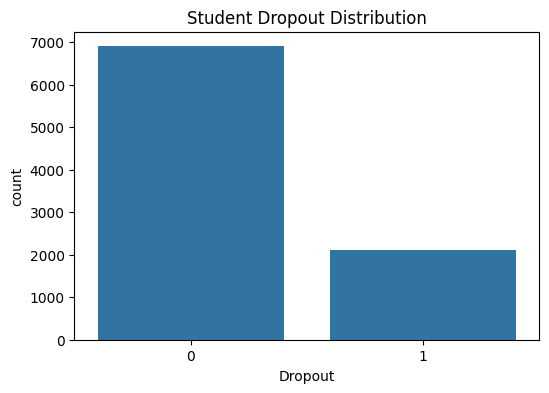

In [ ]:
plt.figure(figsize=(6,4))


sns.countplot(
    x="Dropout",
    data=df
)


plt.title(
"Student Dropout Distribution"
)


plt.show()

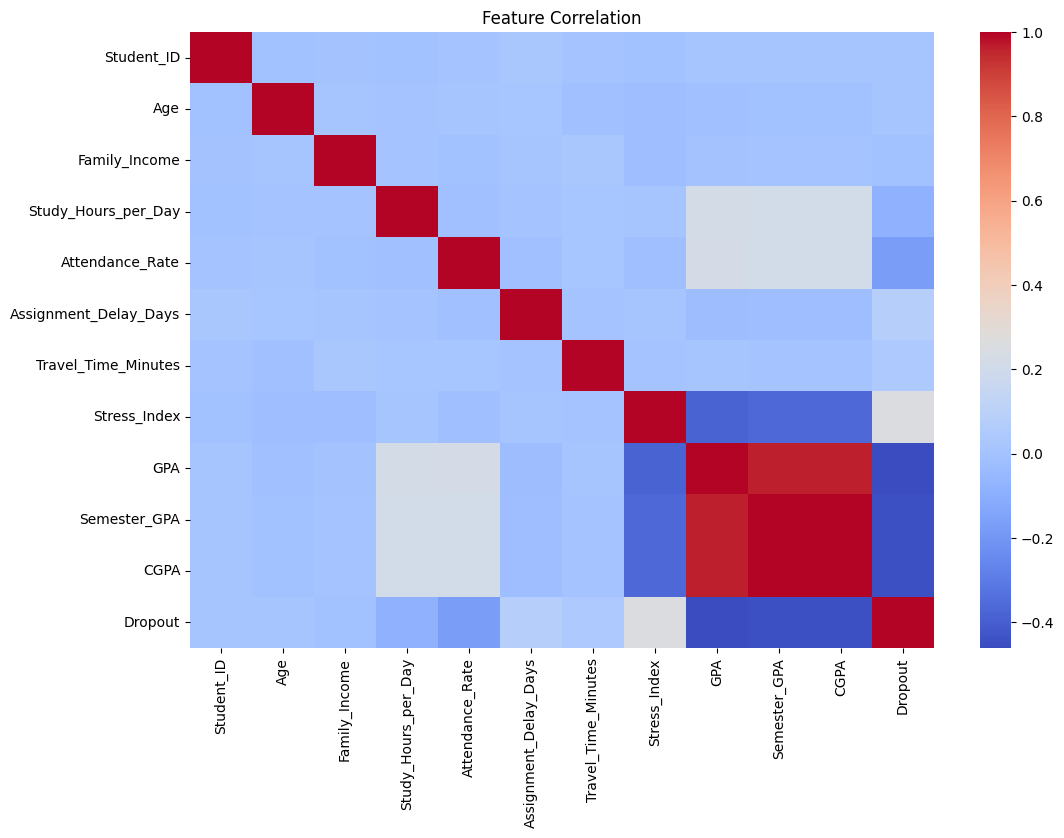

In [ ]:
plt.figure(figsize=(12,8))


sns.heatmap(
    df.corr(numeric_only=True),
    cmap="coolwarm"
)


plt.title(
"Feature Correlation"
)


plt.show()

In [ ]:
encoder = LabelEncoder()


for col in df.select_dtypes(include="object").columns:

    df[col] = encoder.fit_transform(df[col])


df.head()

,Student_ID,Age,Gender,Family_Income,Internet_Access,Study_Hours_per_Day,Attendance_Rate,Assignment_Delay_Days,Travel_Time_Minutes,Part_Time_Job,Scholarship,Stress_Index,GPA,Semester_GPA,CGPA,Semester,Department,Parental_Education,Dropout
0,1,22.1,1,25000.0,1,3.36,86.1,2,20.4,1,0,5.5,0.96,0.90,0.90,0,0,1,0
1,2,20.7,1,25000.0,1,4.30,68.0,2,44.0,0,0,6.8,1.28,1.20,1.19,2,3,0,1
2,3,22.4,1,40183.0,1,4.40,70.9,0,48.9,1,0,5.5,1.68,1.32,1.32,0,0,2,0
4,5,20.5,0,25319.0,1,4.19,75.7,1,23.0,0,0,7.0,1.48,0.91,0.87,3,1,0,0
6,7,24.5,1,25000.0,1,3.00,78.2,1,37.4,1,1,7.3,0.64,0.33,0.44,3,2,0,0


In [ ]:
X = df.drop(
    "Dropout",
    axis=1
)


y = df["Dropout"]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(

X,

y,

test_size=0.2,

random_state=42

)

In [ ]:
scaler = StandardScaler()


X_train = scaler.fit_transform(
    X_train
)


X_test = scaler.transform(
    X_test
)

In [ ]:
lr = LogisticRegression()


lr.fit(
X_train,
y_train
)


lr_pred = lr.predict(
X_test
)

In [ ]:
dt = DecisionTreeClassifier()


dt.fit(
X_train,
y_train
)


dt_pred = dt.predict(
X_test
)

In [ ]:
rf = RandomForestClassifier(

n_estimators=100,

random_state=42

)


rf.fit(
X_train,
y_train
)


rf_pred = rf.predict(
X_test
)

In [ ]:
results = pd.DataFrame({

"Model":[

"Logistic Regression",

"Decision Tree",

"Random Forest"

],


"Accuracy":[

accuracy_score(y_test,lr_pred),

accuracy_score(y_test,dt_pred),

accuracy_score(y_test,rf_pred)

],


"Precision":[

precision_score(y_test,lr_pred),

precision_score(y_test,dt_pred),

precision_score(y_test,rf_pred)

],


"Recall":[

recall_score(y_test,lr_pred),

recall_score(y_test,dt_pred),

recall_score(y_test,rf_pred)

]

})


results

,Model,Accuracy,Precision,Recall
0,Logistic Regression,0.806541,0.676230,0.379310
1,Decision Tree,0.718404,0.421842,0.452874
2,Random Forest,0.803769,0.666667,0.372414


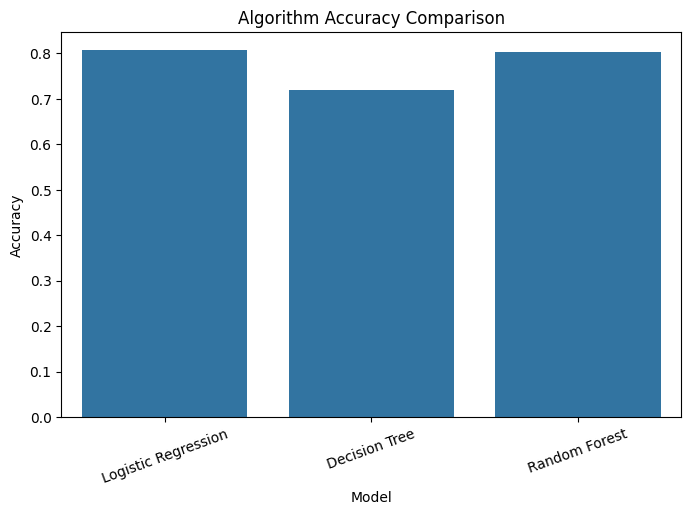

In [ ]:
plt.figure(figsize=(8,5))


sns.barplot(

data=results,

x="Model",

y="Accuracy"

)


plt.xticks(rotation=20)

plt.title(
"Algorithm Accuracy Comparison"
)


plt.show()

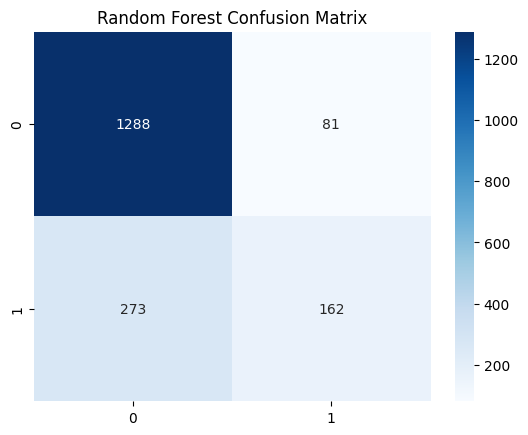

In [ ]:
cm = confusion_matrix(

y_test,

rf_pred

)


sns.heatmap(

cm,

annot=True,

fmt="d",

cmap="Blues"

)


plt.title(
"Random Forest Confusion Matrix"
)


plt.show()

In [ ]:
importance = pd.DataFrame({

"Feature":

X.columns,


"Importance":

rf.feature_importances_

})


importance.sort_values(

by="Importance",

ascending=False

)

,Feature,Importance
12,GPA,0.146855
13,Semester_GPA,0.130462
14,CGPA,0.114625
11,Stress_Index,0.079356
6,Attendance_Rate,0.077085
8,Travel_Time_Minutes,0.069682
0,Student_ID,0.068523
5,Study_Hours_per_Day,0.068007
1,Age,0.061247
3,Family_Income,0.046498


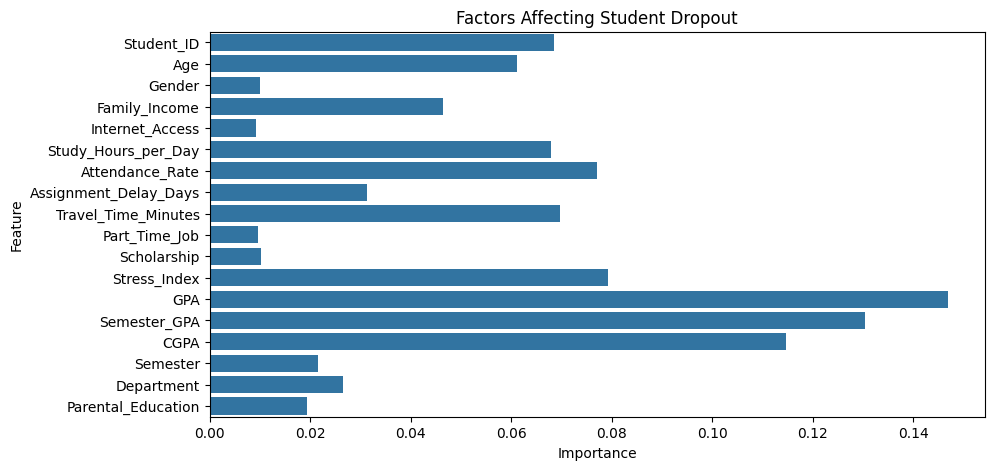

In [ ]:
plt.figure(figsize=(10,5))


sns.barplot(

data=importance,

x="Importance",

y="Feature"

)


plt.title(
"Factors Affecting Student Dropout"
)


plt.show()

In [ ]:
sample = X.iloc[[0]]


sample_scaled = scaler.transform(
sample
)


prediction = rf.predict(
sample_scaled
)


if prediction[0]==1:

    print(
    "⚠ Student is at Dropout Risk"
    )


else:

    print(
    "✅ Student is Safe"
    )

✅ Student is Safe


# Conclusion

The Student Dropout Prediction system was developed using Machine Learning algorithms.

Three models were trained:
- Logistic Regression
- Decision Tree
- Random Forest

Performance was evaluated using:
- Accuracy
- Precision
- Recall

Random Forest provided the best prediction performance and can help institutions identify students who need early support.